# Transformer Attention Visualization

In this notebook, we visualize the attention weights of our Transformer Encoder.
We input a simple sequence of tokens and see which tokens attend to which others in different layers and heads.

In [1]:
import sys
import os

# Add the parent directory to sys.path to import 'src'
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.encoder import TransformerEncoder

# Set up plotting style
sns.set_context("notebook", font_scale=1.2)
%matplotlib inline

In [2]:
# 1. Setup Model
vocab_size = 100
d_model = 32
num_heads = 4
num_layers = 2

# Set seed for reproducibility
torch.manual_seed(42)

encoder = TransformerEncoder(
    vocab_size=vocab_size, 
    d_model=d_model, 
    num_heads=num_heads, 
    num_layers=num_layers
)
encoder.eval()

print("Model created successfully.")

Model created successfully.


In [3]:
# 2. Prepare Input
# Let's imagine a sentence with 5 words: [A, B, C, D, E]
T = 5
x = torch.randint(0, vocab_size, (1, T))
tokens = [f"Token {i}" for i in range(T)]

print(f"Input sequence shape: {x.shape}")
print(f"Tokens: {tokens}")

Input sequence shape: torch.Size([1, 5])
Tokens: ['Token 0', 'Token 1', 'Token 2', 'Token 3', 'Token 4']


In [4]:
# 3. Forward Pass with Attention Return
with torch.no_grad():
    out, attentions = encoder(x, return_attention=True)
    
# attentions is a list of tensors, one per layer
print(f"Output shape: {out.shape}")
print(f"Number of layers: {len(attentions)}")
print(f"Attention map shape (Layer 0): {attentions[0].shape}") # (B, num_heads, T, T)

Output shape: torch.Size([1, 5, 32])
Number of layers: 2
Attention map shape (Layer 0): torch.Size([1, 4, 5, 5])


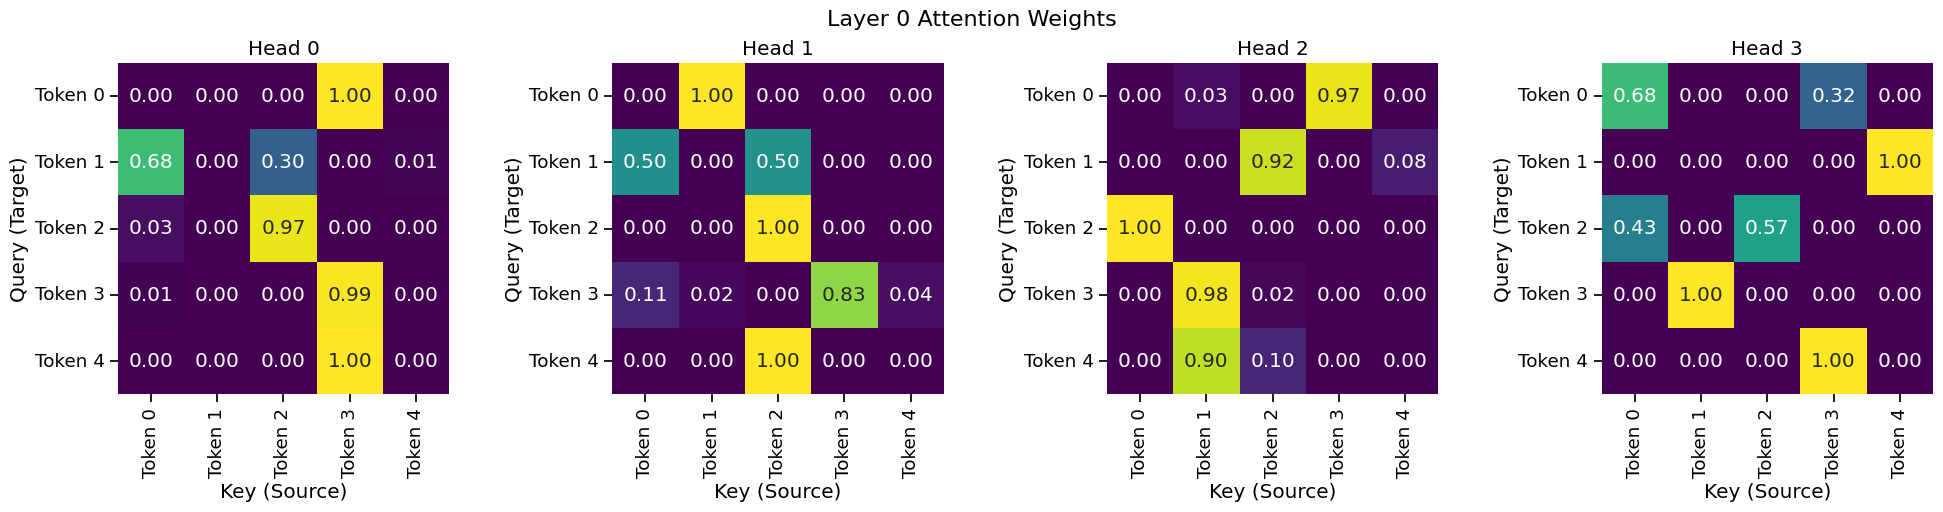

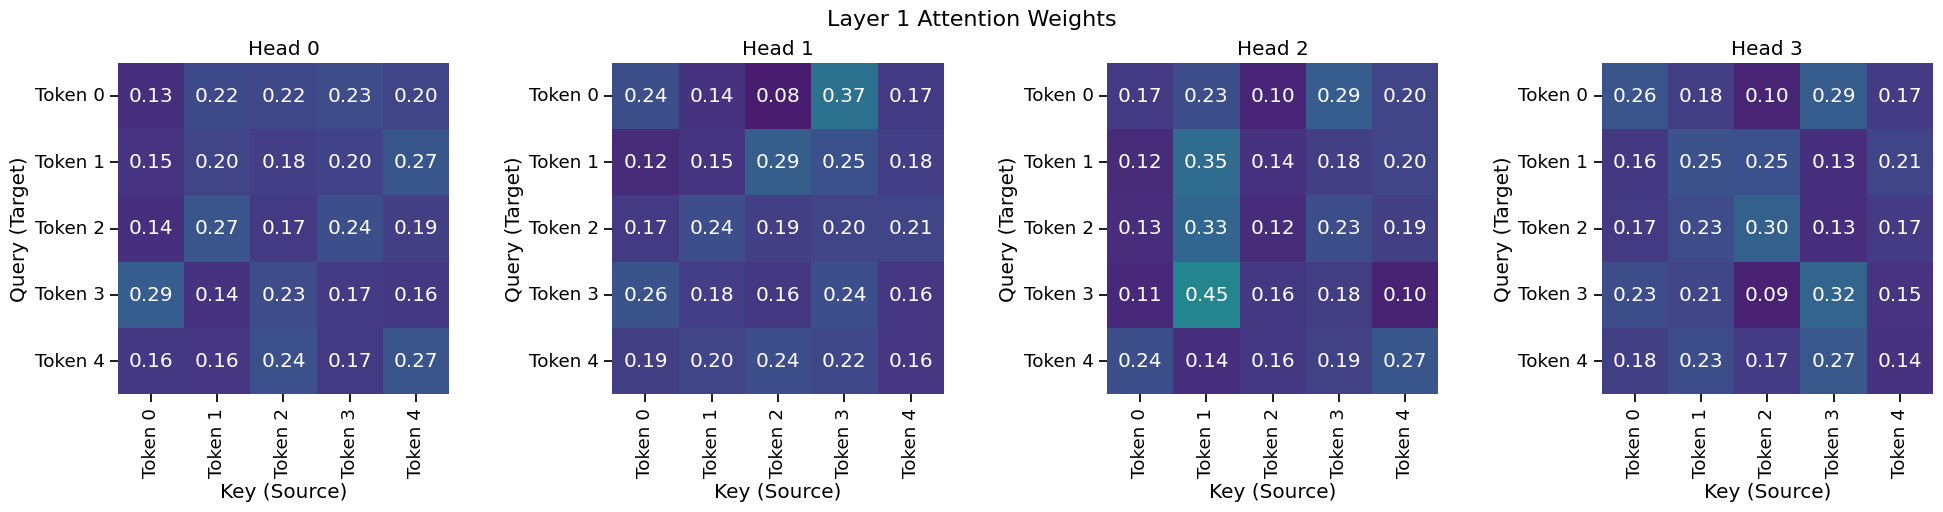

In [5]:
# 4. Plot Attention Maps

def plot_attention_maps(attentions, layer_idx):
    attn_map = attentions[layer_idx][0] # Get first batch item: (num_heads, T, T)
    
    fig, axes = plt.subplots(1, num_heads, figsize=(20, 5))
    
    for h in range(num_heads):
        ax = axes[h]
        
        sns.heatmap(
            attn_map[h], 
            ax=ax, 
            cmap="viridis", 
            vmin=0, vmax=1,
            xticklabels=tokens,
            yticklabels=tokens,
            cbar=False,
            annot=True, # Show values
            fmt=".2f",
            square=True
        )
        
        ax.set_title(f"Head {h}")
        ax.set_xlabel("Key (Source)")
        ax.set_ylabel("Query (Target)")
    
    plt.suptitle(f"Layer {layer_idx} Attention Weights", fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize Layer 0
plot_attention_maps(attentions, layer_idx=0)

# Visualize Layer 1
plot_attention_maps(attentions, layer_idx=1)